In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder.appName("adsP1")
    .config("spark.sql.repl.eagerEval.enabled", True)
    .config("spark.driver.memory", "8G")
    .config("spark.executor.memory", "8G")
    .config("spark.sql.parquet.cacheMetadata", "true")
    .config("spark.sql.session.timeZone", "Etc/UTC")
    .getOrCreate()
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/08/24 23:52:41 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
24/08/24 23:52:42 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.functions import col
from pyspark.sql.functions import count
from pyspark.sql.functions import format_number
from pyspark.sql.functions import unix_timestamp
from pyspark.sql.functions import date_trunc
from pyspark.sql.functions import round
from pyspark.sql.functions import mean, stddev, sqrt
from pyspark.sql.functions import date_format
from pyspark.sql.functions import avg
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler
from pyspark.ml.stat import Correlation
from IPython.display import display
from pyspark.ml import Pipeline
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
from pyspark.sql.functions import log


In [3]:
# load the saved data
df_2022 = spark.read.parquet("/Users/tianhao/Desktop/adsP1/data/curate/tlc_data/first_clean/df_combined_2022.parquet")
df_2023 = spark.read.parquet("/Users/tianhao/Desktop/adsP1/data/curate/tlc_data/first_clean/df_combined_2023.parquet")
df_all = spark.read.parquet("/Users/tianhao/Desktop/adsP1/data/curate/tlc_data/first_clean/df_all.parquet")

#

##  1. See order counts in each day of week of 2022 & 2023 Autumn

In [4]:
# Sort by day of week

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_order_expr = F.when(F.col("day_of_week") == "Monday", 1) \
                 .when(F.col("day_of_week") == "Tuesday", 2) \
                 .when(F.col("day_of_week") == "Wednesday", 3) \
                 .when(F.col("day_of_week") == "Thursday", 4) \
                 .when(F.col("day_of_week") == "Friday", 5) \
                 .when(F.col("day_of_week") == "Saturday", 6) \
                 .when(F.col("day_of_week") == "Sunday", 7)

trip_2022_number_weekday = df_2022.groupBy("day_of_week").count().orderBy(day_order_expr).toPandas()
trip_2023_number_weekday = df_2023.groupBy("day_of_week").count().orderBy(day_order_expr).toPandas()
trip_2022_number_weekday.columns = ["2022", "Order_counts"]
trip_2023_number_weekday.columns = ["2023", "Order_counts"]
print(trip_2022_number_weekday.to_string(index=False))

print(trip_2023_number_weekday.to_string(index=False))

     2022  Order_counts
   Monday       1211392
  Tuesday       1357533
Wednesday       1403741
 Thursday       1404255
   Friday       1399568
 Saturday       1333846
   Sunday       1077520
     2023  Order_counts
   Monday       1147843
  Tuesday       1334391
Wednesday       1397829
 Thursday       1378444
   Friday       1240381
 Saturday       1244679
   Sunday       1078208


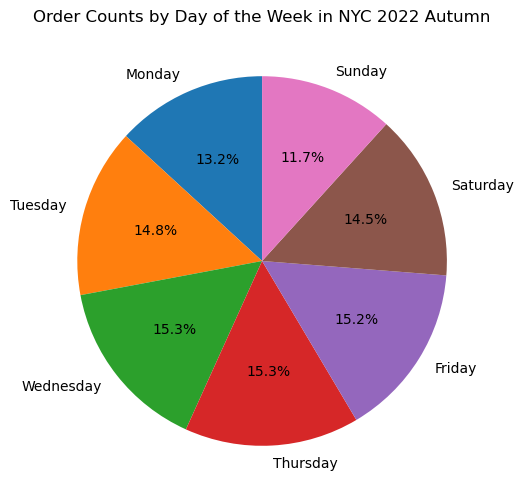

In [5]:
# Create a pie chart for 2022
days_2022 = trip_2022_number_weekday['2022']
order_counts_2022 = trip_2022_number_weekday['Order_counts']

plt.figure(figsize=(10, 6))
plt.pie(order_counts_2022, labels=days_2022, autopct='%1.1f%%', startangle=90)
plt.title('Order Counts by Day of the Week in NYC 2022 Autumn')
plt.savefig('/Users/tianhao/Desktop/adsP1/plot/autumn_2022_pie_chart.png')
plt.show()

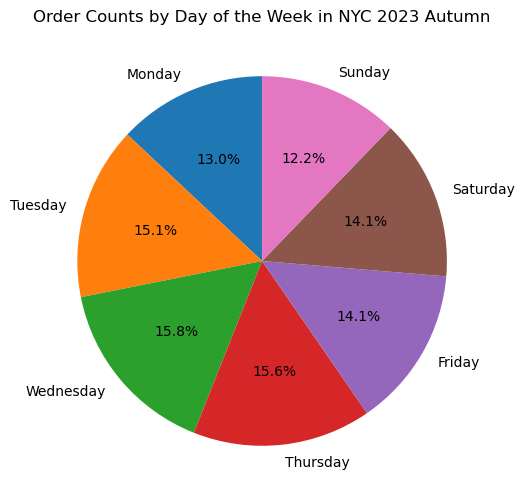

In [6]:
# Create a pie chart for 2023
days_2023 = trip_2023_number_weekday['2023']
order_counts_2023 = trip_2023_number_weekday['Order_counts']

plt.figure(figsize=(10, 6))
plt.pie(order_counts_2023, labels=days_2023, autopct='%1.1f%%', startangle=90)
plt.title('Order Counts by Day of the Week in NYC 2023 Autumn')
plt.savefig('/Users/tianhao/Desktop/adsP1/plot/autumn_2023_pie_chart.png')
plt.show()

# 2. Find is there any patterns of orders demand in each hour of one day?

In [7]:
# See demand for each hour of the day in autumn
autumn_day = 91
trip_2022_number_hour = df_2022.groupBy("hour").count().orderBy("hour").toPandas()
trip_2022_number_hour['average_count'] = trip_2022_number_hour['count'] / autumn_day

trip_2023_number_hour = df_2023.groupBy("hour").count().orderBy("hour").toPandas()
trip_2023_number_hour['average_count'] = trip_2023_number_hour['count'] / autumn_day

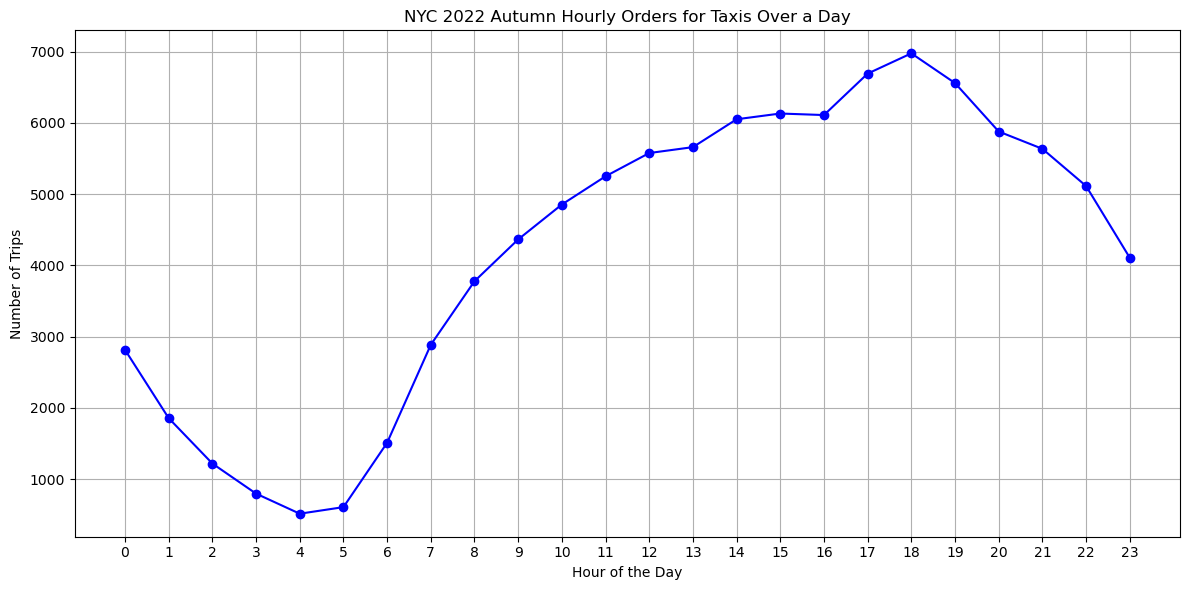

In [8]:
plot_2022_hour = trip_2022_number_hour 

plt.figure(figsize=(12, 6))
plt.plot(plot_2022_hour['hour'], plot_2022_hour['average_count'], marker='o', linestyle='-', color='b')
plt.title('NYC 2022 Autumn Hourly Orders for Taxis Over a Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('/Users/tianhao/Desktop/adsP1/plot/autumn_2022_hourly_Orders.png')
plt.show()

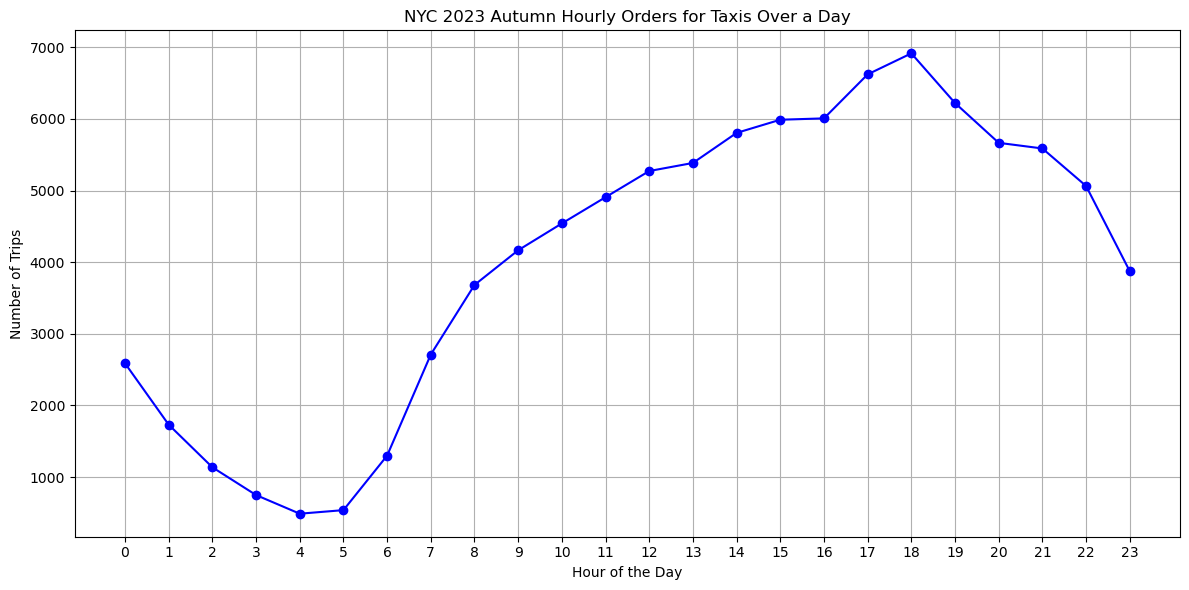

In [9]:
plot_2023_hour = trip_2023_number_hour 

plt.figure(figsize=(12, 6))
plt.plot(plot_2023_hour['hour'], plot_2023_hour['average_count'], marker='o', linestyle='-', color='b')
plt.title('NYC 2023 Autumn Hourly Orders for Taxis Over a Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.grid(True)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.savefig('/Users/tianhao/Desktop/adsP1/plot/autumn_2023_Orders_demand.png')
plt.show()

# 3. Pick out peak hour in morning is 7 - 9 A.M. / evening is 17 - 19 P.M.

## See what factors impact orders demand

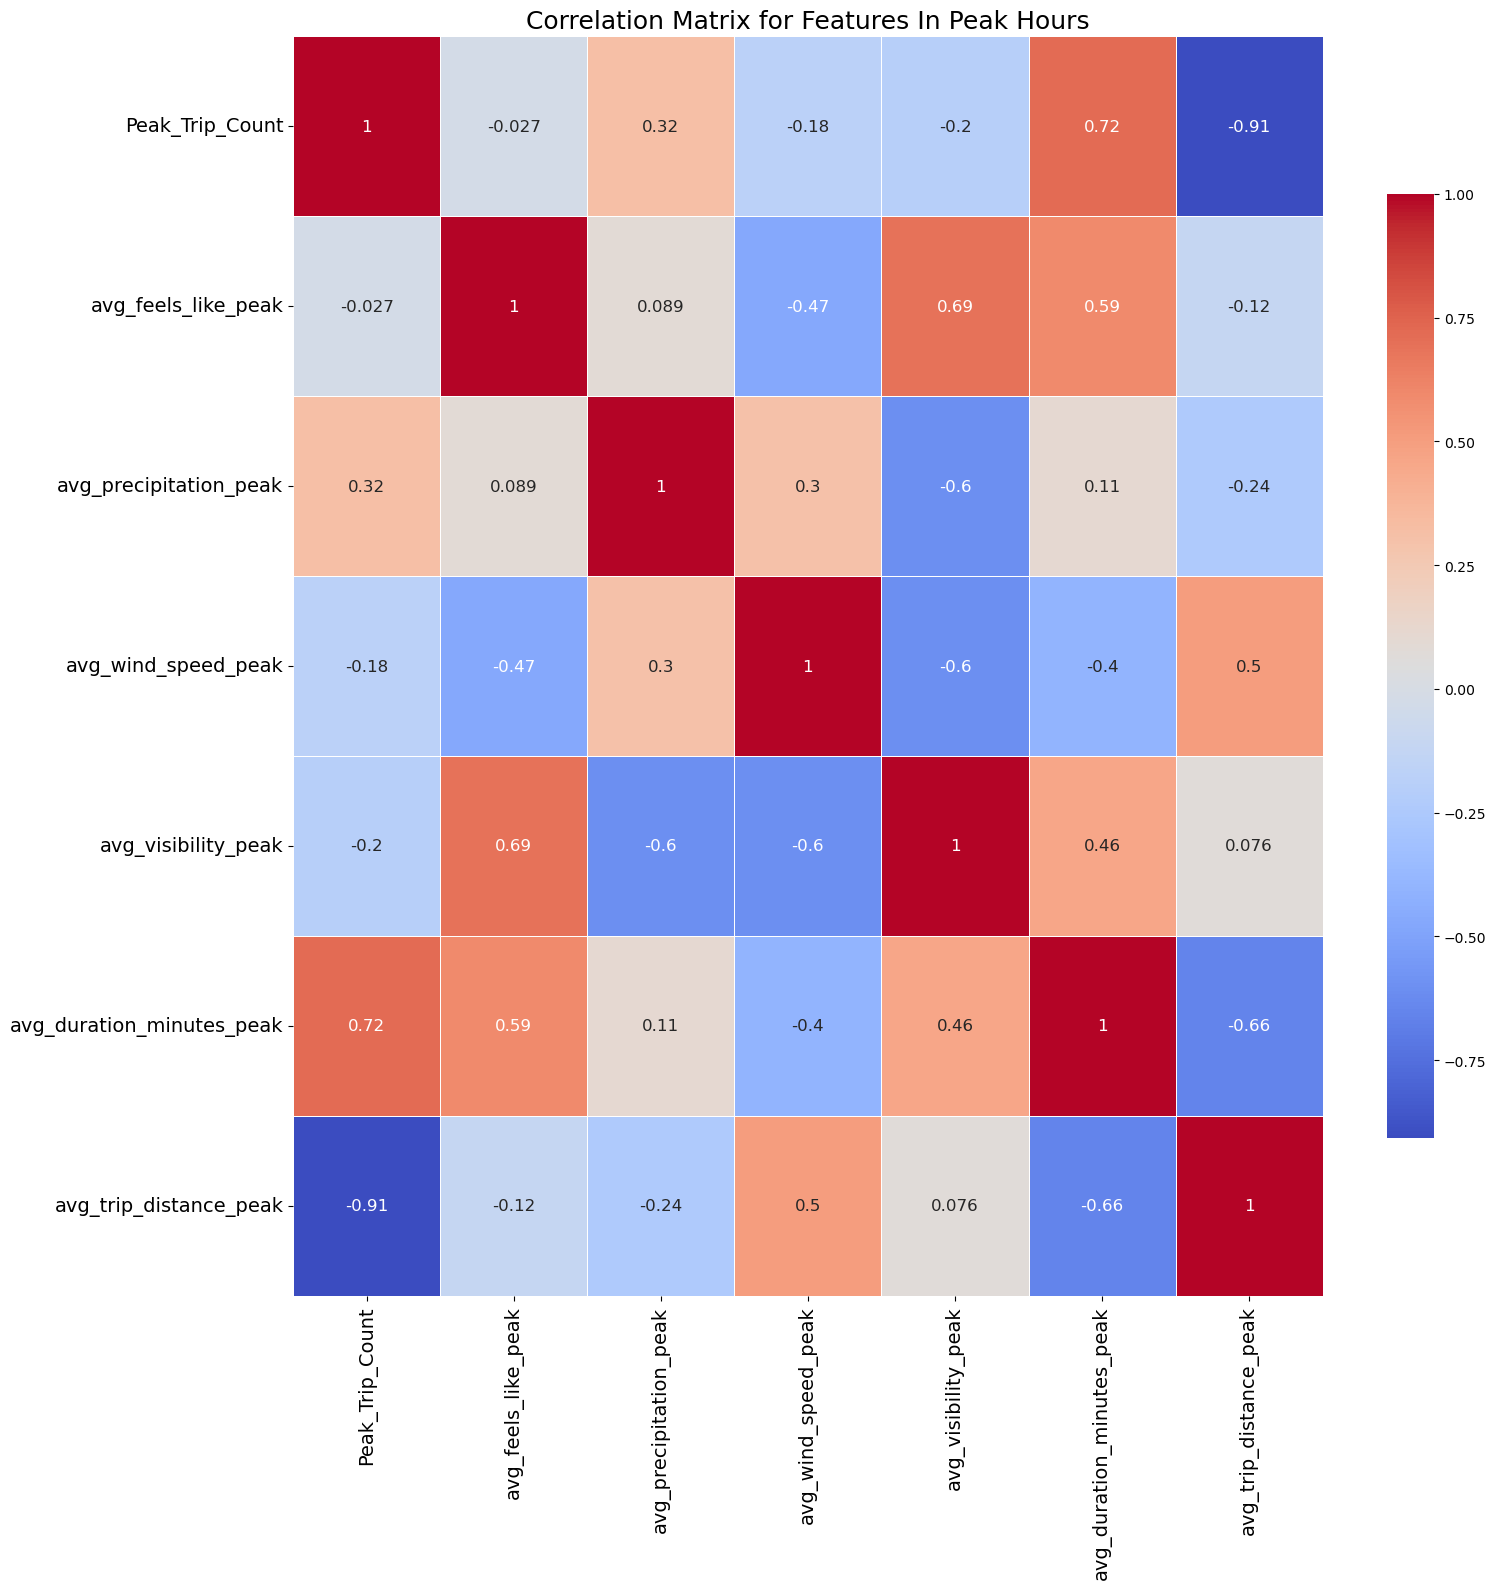

In [17]:
# Select the feature column for which the correlation is to be calculated

feature_columns = ['Peak_Trip_Count',
                   'avg_feels_like_peak',
                    'avg_precipitation_peak',
                      'avg_wind_speed_peak',
                        'avg_visibility_peak',
                        "avg_duration_minutes_peak",
                        "avg_trip_distance_peak"]

# Create an empty DataFrame to store the correlation coefficients
corr_matrix = []

# Calculate the correlation coefficient between each pair of features
for col1 in feature_columns:
    row = []
    for col2 in feature_columns:
        corr_value = df_all.stat.corr(col1, col2)  # Use PySpark's datafame.stat.corr method
        row.append(corr_value)
    corr_matrix.append(row)

# Convert the list to Pandas DataFrame
pd_corr_matrix = pd.DataFrame(corr_matrix, index=feature_columns, columns=feature_columns)

plt.figure(figsize=(16, 16))  
sns.heatmap(pd_corr_matrix, annot=True, cmap='coolwarm', linewidths=.5, annot_kws={"size": 12}, cbar_kws={'shrink': 0.75})
plt.title('Correlation Matrix for Features In Peak Hours', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout() 
plt.savefig('/Users/tianhao/Desktop/adsP1/plot/Correlation_matrix_peak_hour.png')
plt.show()


## 

In [11]:
# pick up the peak_hours records
peak_hours_df = df_all.filter(col("is_peak_hour") == 1)
peak_hours_df.printSchema()

root
 |-- day_of_week: string (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- total_revenue: double (nullable = true)
 |-- duration_minutes: double (nullable = true)
 |-- feels_like: double (nullable = true)
 |-- precipitation: double (nullable = true)
 |-- wind_speed: double (nullable = true)
 |-- visibility: double (nullable = true)
 |-- hour: integer (nullable = true)
 |-- is_peak_hour: integer (nullable = true)
 |-- avg_feels_like_peak: double (nullable = true)
 |-- avg_precipitation_peak: double (nullable = true)
 |-- avg_wind_speed_peak: double (nullable = true)
 |-- avg_visibility_peak: double (nullable = true)
 |-- avg_duration_minutes_peak: double (nullable = true)
 |-- avg_tr

In [12]:
peak_hours_df = peak_hours_df.drop("tpep_dropoff_datetime","passenger_count", "RatecodeID", "PULocationID", "DOLocationID",
                   "is_peak_hour", "avg_feels_like_peak", "avg_precipitation_peak", "avg_wind_speed_peak",
                   "avg_visibility_peak", "avg_duration_minutes_peak", "avg_trip_distance_peak", "Peak_Trip_Count",
                   "day_of_week","feels_like")

In [13]:
# Aggregate the number of orders per hour by hour
hourly_order_counts = peak_hours_df.groupBy(date_format("tpep_pickup_datetime", "yyyy-MM-dd HH").alias("hour")).agg(count("*").alias("order_count")).orderBy("hour")
hourly_order_counts

hour,order_count
2022-09-01 07,2998
2022-09-01 08,4122
2022-09-01 09,4753
2022-09-01 17,6746
2022-09-01 18,7147
2022-09-01 19,6184
2022-09-02 07,2370
2022-09-02 08,3372
2022-09-02 09,3912
2022-09-02 17,6324


In [14]:
from pyspark.sql.functions import col, hour, date_format, avg, count

hourly_stats = peak_hours_df.groupBy(date_format("tpep_pickup_datetime", "yyyy-MM-dd HH").alias("hour")).agg(
    count("*").alias("order_count"),
    avg("trip_distance").alias("avg_trip_distance"),
    avg("duration_minutes").alias("avg_duration_minutes"),
    avg("precipitation").alias("avg_precipitation"),
    avg("wind_speed").alias("avg_wind_speed"),
    avg("visibility").alias("avg_visibility")
)
hourly_stats.show()

+-------------+-----------+------------------+--------------------+--------------------+------------------+-----------------+
|         hour|order_count| avg_trip_distance|avg_duration_minutes|   avg_precipitation|    avg_wind_speed|   avg_visibility|
+-------------+-----------+------------------+--------------------+--------------------+------------------+-----------------+
|2022-10-29 09|       3695|3.3618971583220567|  12.960947225981055|                 0.0| 6.400000000000269|9.900000000000688|
|2022-11-16 07|       3134|3.3518921506062545|  16.139629865985945|0.015999999999998803| 7.299999999999579|3.200000000000028|
|2022-10-27 19|       8213|3.2928966272981777|   16.88005600876655|                 0.0|12.399999999998586|9.899999999999698|
|2022-11-02 17|       7982| 3.108233525432218|  18.943710849411154|                 0.0|2.2000000000003284|9.899999999999858|
|2022-10-05 08|       4506| 2.990297381269422|  14.507656458055905|                 0.0| 4.900000000000185|5.900000000